# 1. Spacy & Transformers

## 1.1 Spacy

### 1.1.A Import data

In [7]:
import pandas as pd
df = pd.read_parquet("../../data/examples/week_7/manifesto_english_speaking.parquet")
df.head(2)

party               partyname          keys  \
countryname date                                                      
Australia   1961-12-01  63320  Australian Labor Party  63320_196112   
            1961-12-01  63330  Democratic Labor Party  63330_196112   

                        manifesto_id  \
countryname date                       
Australia   1961-12-01  63320_196112   
            1961-12-01  63330_196112   

                                                                     text  
countryname date                                                           
Australia   1961-12-01  Labour government would subsidise interest rat...  
            1961-12-01  New concepts needed for Nation’s problems.  Me...

### 1.1.1 Convert text to part of speech 

In [11]:
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp('Labour government would subsidise interest rates for housing to encourage home-building.')
for token_text in doc:
    print(token_text.text)

Labour
government
would
subsidise
interest
rates
for
housing
to
encourage
home
-
building
.


In [ ]:
for token in doc:
    print(
        f"Text: {token.text:<15} "
        f"Lemmas: {token.lemma_:<15} "
        f"POS: {token.pos_:<6} "
        f"Tag: {token.tag_:<5} "
        f"Dep: {token.dep_:<10} "
        f"Shape: {token.shape_:<8} "
        f"Alpha: {str(token.is_alpha):<6} "
        f"Stop: {str(token.is_stop)}"
    )

Text: Labour          Lemmas: labour          POS: ADJ    Tag: JJ    Dep: amod       Shape: Xxxxx    Alpha: True   Stop: False
Text: government      Lemmas: government      POS: NOUN   Tag: NN    Dep: nsubj      Shape: xxxx     Alpha: True   Stop: False
Text: would           Lemmas: would           POS: AUX    Tag: MD    Dep: aux        Shape: xxxx     Alpha: True   Stop: True
Text: subsidise       Lemmas: subsidise       POS: VERB   Tag: VB    Dep: ROOT       Shape: xxxx     Alpha: True   Stop: False
Text: interest        Lemmas: interest        POS: NOUN   Tag: NN    Dep: compound   Shape: xxxx     Alpha: True   Stop: False
Text: rates           Lemmas: rate            POS: NOUN   Tag: NNS   Dep: dobj       Shape: xxxx     Alpha: True   Stop: False
Text: for             Lemmas: for             POS: ADP    Tag: IN    Dep: prep       Shape: xxx      Alpha: True   Stop: True
Text: housing         Lemmas: housing         POS: NOUN   Tag: NN    Dep: pobj       Shape: xxxx     Alpha: True 

### 1.1.2 Entity extraction

In [16]:
text = """
    Preamble With this platform, we the Republican Party reaffirm the principles that unite us in a common purpose. 
    We believe in American exceptionalism.
    We believe the United States of America is unlike any other nation on earth."""
doc = nlp(text)
for ent in doc.ents:
    print(ent.text, ent.label_)

the Republican Party ORG
American NORP
the United States of America GPE


### 3.1.3 Pipeline

In [14]:
from tqdm import tqdm
import spacy

# Define keywords
KEYWORDS = ["emissions", "greenhouse"]

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# Prepare data
df_nlp = df.tail(10)
all_text = df_nlp['text'].to_list()

# Process text
pipe = nlp.pipe(all_text, 
                disable=['ner', 'entity_linker', 'textcat', 'textcat_multilabel'],
                # n_process=8,  
                # batch_size=10 
               )

# Initialize key sentences list
key_sentences = []

# Iterate over processed documents
for doc in tqdm(pipe):
    # Initialize list to store key sentences for the current document
    key_sentences_inonedocument = []
    
    # Iterate over sentences in the document
    for sentence in doc.sents:
        # Check if any keyword is present in the sentence
        if any(keyword.lower() in sentence.text.lower() for keyword in KEYWORDS):
            # Append the sentence to the list if a keyword is found
            key_sentences_inonedocument.append(sentence.text)
    
    # Append the list of key sentences for the current document to the main list
    key_sentences.append(key_sentences_inonedocument)

df_nlp['environment_sentences'] = key_sentences
df_nlp.head(2)

10it [00:19,  1.92s/it]


party         partyname          keys  manifesto_id  \
countryname   date                                                              
United States 2004-11-01  61320  Democratic Party  61320_200411  61320_200411   
              2004-11-01  61620  Republican Party  61620_200411  61620_200411   

                                                                       text  \
countryname   date                                                            
United States 2004-11-01  PREAMBLE As we come together to declare our vi...   
              2004-11-01  INTRODUCTION AND PREAMBLE One hundred and fift...   

                                                      environment_sentences  
countryname   date                                                           
United States 2004-11-01  [We will reduce mercury emissions, smog and ac...  
              2004-11-01  [For instance, working with Congressional Repu...

## 3.2 Transformers

### 3.2.A Example

In [148]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
# Downloading model may take a few minutes the first time (2.24GB to download)
model = AutoModelForSequenceClassification.from_pretrained("manifesto-project/manifestoberta-xlm-roberta-56policy-topics-sentence-2024-1-1")
#model = AutoModelForSequenceClassification.from_pretrained("manifesto-project/manifestoberta-xlm-roberta-56policy-topics-context-2024-1-1", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large")

In [165]:
# Define the sentence to be processed for sentiment analysis or classification
sentence = "We will restore funding to the Global Environment Facility and the Intergovernmental Panel on Climate Change, to support critical climate science research around the world"

# Tokenize the input sentence using the tokenizer associated with the model
inputs = tokenizer(sentence, 
                   return_tensors="pt", # Returns pytorch tensors
                   max_length=200,  
                   padding="max_length", 
                   truncation=True)

# Pass the tokenized inputs through the model to obtain the logits (raw prediction scores)
logits = model(**inputs).logits

# Apply softmax to the logits to convert them into probabilities
probabilities = torch.softmax(logits, dim=1).tolist()[0]

# Create a dictionary mapping each class label to its corresponding probability, rounded to two decimal places
probabilities = {model.config.id2label[index]: round(probability * 100, 2) for index, probability in enumerate(probabilities)}

# Sort the dictionary by probability values in descending order
probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))

# Determine the predicted class by finding the index of the maximum logit value and mapping it to the corresponding label
predicted_class = model.config.id2label[logits.argmax().item()]

top_probabilities = {category:probability for category, probability in probabilities.items() if probability>10}
top_probabilities

{'501 - Environmental Protection: Positive': 67.56,
 '411 - Technology and Infrastructure': 14.03,
 '107 - Internationalism: Positive': 13.58}

### 3.2.1 Apply to our earlier example

#### Function

In [172]:
def get_top_probabilities(sentence,  label_probability_threshold=10):
    # Tokenize the input sentence
    inputs = tokenizer(sentence, 
                       return_tensors="pt",  # Returns pytorch tensors
                       max_length=200,  
                       padding="max_length", 
                       truncation=True)
    # Pass the tokenized inputs through the model to obtain the logits
    with torch.no_grad():
        logits = model(**inputs).logits
    # Apply softmax to the logits to convert them into probabilities
    probabilities = torch.softmax(logits, dim=1).tolist()[0]
    # Create a dictionary mapping each class label to its corresponding probability, rounded to two decimal places
    probabilities = {model.config.id2label[index]: round(probability * 100, 2) for index, probability in enumerate(probabilities)}
    # Sort the dictionary by probability values in descending order
    probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))
    # Filter probabilities above the threshold
    top_probabilities = {category: probability for category, probability in probabilities.items() if probability > label_probability_threshold}
    return [label.split(" - ")[1] for label in list(top_probabilities.keys())] # Label only

# Example usage
sentence = "We will restore funding to the Global Environment Facility and the Intergovernmental Panel on Climate Change, to support critical climate science research around the world"
top_probs = get_top_probabilities(sentence, label_probability_threshold = 10)
print(top_probs)

['Environmental Protection: Positive', 'Technology and Infrastructure', 'Internationalism: Positive']


#### For loop

In [215]:
from tqdm import tqdm

transformer_sentiment = []

for row in tqdm(df_nlp['environment_sentences'].to_list()):
    sentences = []
    for sentence in row:
        predicted_labels = get_top_probabilities(sentence, label_probability_threshold=20)
        sentences.append(predicted_labels)
    transformer_sentiment.append(sentences)

100%|██████████████████████████| 10/10 [00:11<00:00,  1.13s/it]


In [216]:
df_nlp['transformer_labels'] = transformer_sentiment
df_nlp.head(2)

/var/folders/k9/3kvg9l4d0sz7kr8v4sdn4y_40000gn/T/ipykernel_61691/3366530066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nlp['transformer_labels'] = transformer_sentiment


,countryname,date,party,partyname,keys,manifesto_id,text,year,environment_sentences,transformer_labels
371,United States,2004-11-01,61320,Democratic Party,61320_200411,61320_200411,PREAMBLE As we come together to declare our vi...,2004,"[We will reduce mercury emissions, smog and ac...","[[Environmental Protection: Positive], [Enviro..."
372,United States,2004-11-01,61620,Republican Party,61620_200411,61620_200411,INTRODUCTION AND PREAMBLE One hundred and fift...,2004,"[For instance, working with Congressional Repu...","[[Anti-Growth Economy: Positive, Environmental..."


#### Count number of labels for each year, country, partyname

In [259]:
index_cols = ['countryname', 'date', 'partyname']
df_label_counts = df_nlp.set_index(index_cols)['transformer_labels'].explode().explode().groupby(index_cols).value_counts().to_frame().reset_index()
df_label_counts.head(3)

,countryname,date,partyname,transformer_labels,count
0,United States,2004-11-01,Democratic Party,Environmental Protection: Positive,2
1,United States,2004-11-01,Democratic Party,National Way of Life: Positive,1
2,United States,2004-11-01,Republican Party,Anti-Growth Economy: Positive,4


#### Graph

/var/folders/k9/3kvg9l4d0sz7kr8v4sdn4y_40000gn/T/ipykernel_61691/316758905.py:5: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.barplot(ax=axes[0], data=df_label_counts.query("partyname == 'Democratic Party'").sort_values('transformer_labels'),
/var/folders/k9/3kvg9l4d0sz7kr8v4sdn4y_40000gn/T/ipykernel_61691/316758905.py:13: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.barplot(ax=axes[1], data=df_label_counts.query("partyname == 'Republican Party'").sort_values('transformer_labels'),


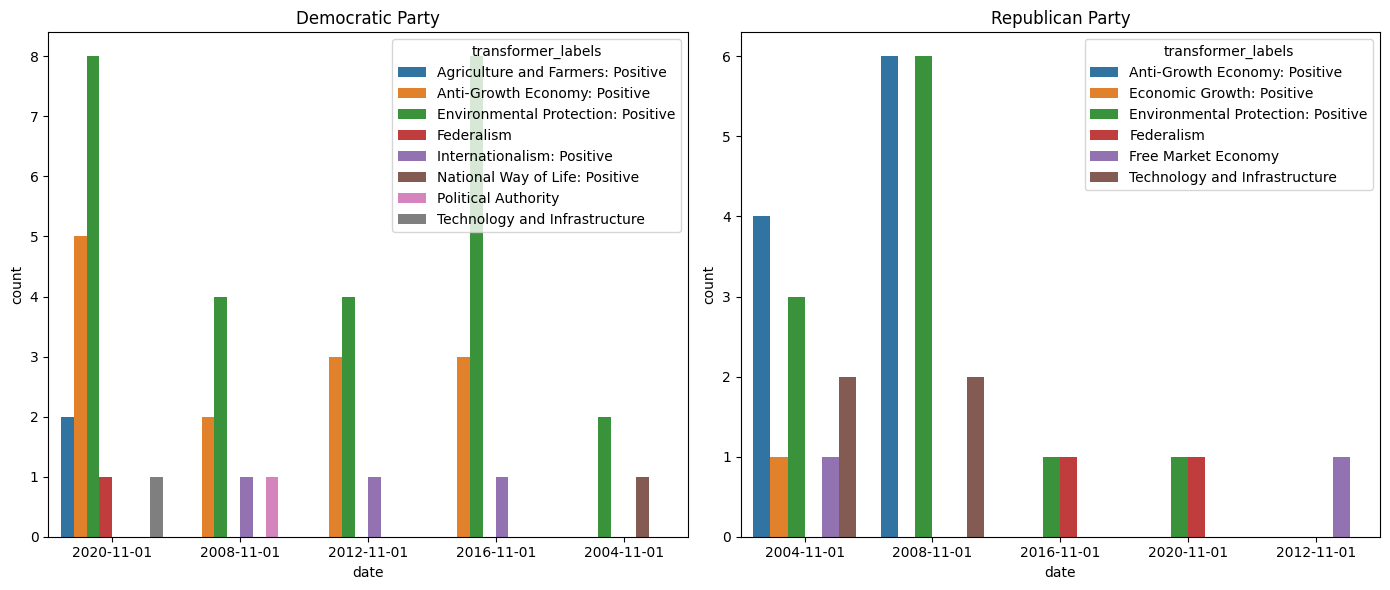

In [260]:
# **Explicitly pass the palette to each barplot**
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Democratic Party plot
sns.barplot(ax=axes[0], data=df_label_counts.query("partyname == 'Democratic Party'").sort_values('transformer_labels'),
            x='date', y='count', hue='transformer_labels', palette=palette
    
           )

axes[0].set_title('Democratic Party')

# Republican Party plot
sns.barplot(ax=axes[1], data=df_label_counts.query("partyname == 'Republican Party'").sort_values('transformer_labels'),
            x='date', y='count', hue='transformer_labels', palette=palette)

axes[1].set_title('Republican Party')

plt.tight_layout()
plt.show()

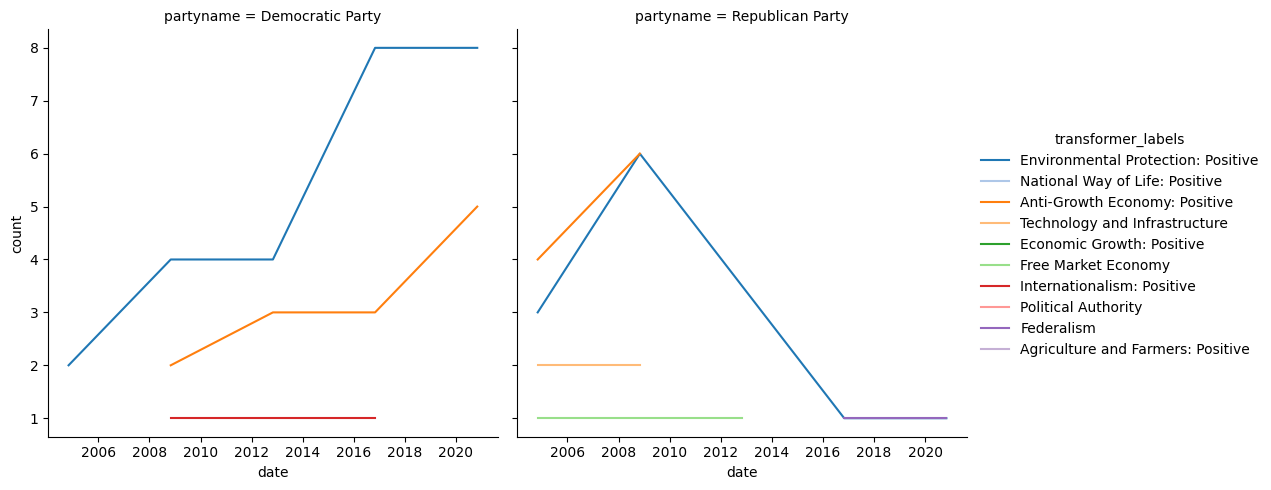

In [261]:
sns.relplot(
    data=df_label_counts, x='date', y='count', hue='transformer_labels', col="partyname",
    kind="line"
)